# Early Dementia Detection from Brain MRI
### Custom 6-Block CNN for Ordinal Classification
**Author:** Gemini AI (Adaptive AI Collaborator)  
**Methodology:** * **Data:** OASIS MRI Dataset (80,000+ images, 461 Patients).
* **Architecture:** Custom 6-Block CNN (Target: 3.9M Parameters).
* **Robustness:** Patient-level splitting to prevent data leakage.
* **Optimization:** Ordinal classification using Sparse Categorical Crossentropy.

In [1]:
from google.colab import drive
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from PIL import Image
from tqdm import tqdm

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define Paths (Update 'OASIS_Project' to your folder name in Drive)
PROJECT_FOLDER = '/content/drive/MyDrive/OASIS_Project'
ZIP_NAME = 'OASIS_Data.zip'
ZIP_PATH = os.path.join(PROJECT_FOLDER, ZIP_NAME)
EXTRACT_PATH = '/content/dataset'

# 3. Extract Dataset to Local Colab SSD for Speed
if os.path.exists(ZIP_PATH):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
    print("✅ Success: Dataset extracted to /content/dataset")
else:
    print(f"❌ Error: Could not find {ZIP_NAME} at {ZIP_PATH}")

Mounted at /content/drive
✅ Success: Dataset extracted to /content/dataset


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Check exactly where the folders are
!ls -R /content/dataset | head -n 20

/content/dataset:
Data

/content/dataset/Data:
Mild Dementia
Moderate Dementia
Non Demented
Very mild Dementia

/content/dataset/Data/Mild Dementia:
OAS1_0028_MR1_mpr-1_100.jpg
OAS1_0028_MR1_mpr-1_101.jpg
OAS1_0028_MR1_mpr-1_102.jpg
OAS1_0028_MR1_mpr-1_103.jpg
OAS1_0028_MR1_mpr-1_104.jpg
OAS1_0028_MR1_mpr-1_105.jpg
OAS1_0028_MR1_mpr-1_106.jpg
OAS1_0028_MR1_mpr-1_107.jpg
OAS1_0028_MR1_mpr-1_108.jpg
OAS1_0028_MR1_mpr-1_109.jpg


## 3. Metadata Extraction
We extract the **Patient ID** and **Slice ID** from filenames to ensure we can split the data by "Human" rather than by "Image."
Filenames follow the convention: `OAS1_0001_MR1_mpr-1_150.jpg`.

In [4]:
DATA_PATH = '/content/dataset/Data'

# Define category mapping for Ordinal Classification
categories = {
    'Non Demented': 0,
    'Very mild Dementia': 1,
    'Mild Dementia': 2,
    'Moderate Dementia': 3
}

def create_metadata_df(base_path):
    data = []
    # Regex pattern for OASIS naming convention
    pattern = re.compile(r'OAS1_(\d+)_MR(\d+)_mpr-(\d+)_(\d+).jpg')

    for folder, label in categories.items():
        folder_path = os.path.join(base_path, folder)

        if not os.path.exists(folder_path):
            print(f"⚠️ Warning: Folder not found: {folder_path}")
            continue

        print(f"Reading folder: {folder}...")
        for filename in os.listdir(folder_path):
            match = pattern.match(filename)
            if match:
                data.append({
                    'path': os.path.join(folder_path, filename),
                    'patient_id': match.group(1),
                    'slice_id': int(match.group(4)),
                    'label': label,
                    'category': folder
                })
    return pd.DataFrame(data)

# Run the ingestion
df = create_metadata_df(DATA_PATH)

if len(df) > 0:
    print(f"\n✅ Success! Total Scans Loaded: {len(df)}")
    print(f"Unique Patients: {df['patient_id'].nunique()}")
    print(f"Slice Range: {df['slice_id'].min()} to {df['slice_id'].max()}")
    display(df.head())
else:
    print("❌ Error: DataFrame is still empty. Check if the filenames match the regex.")

Reading folder: Non Demented...
Reading folder: Very mild Dementia...
Reading folder: Mild Dementia...
Reading folder: Moderate Dementia...

✅ Success! Total Scans Loaded: 86437
Unique Patients: 347
Slice Range: 100 to 160


,path,patient_id,slice_id,label,category
0,/content/dataset/Data/Non Demented/OAS1_0279_M...,0279,119,0,Non Demented
1,/content/dataset/Data/Non Demented/OAS1_0236_M...,0236,115,0,Non Demented
2,/content/dataset/Data/Non Demented/OAS1_0280_M...,0280,126,0,Non Demented
3,/content/dataset/Data/Non Demented/OAS1_0153_M...,0153,124,0,Non Demented
4,/content/dataset/Data/Non Demented/OAS1_0353_M...,0353,154,0,Non Demented


/tmp/ipykernel_429/744804367.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='category', order=categories.keys(), palette='magma')


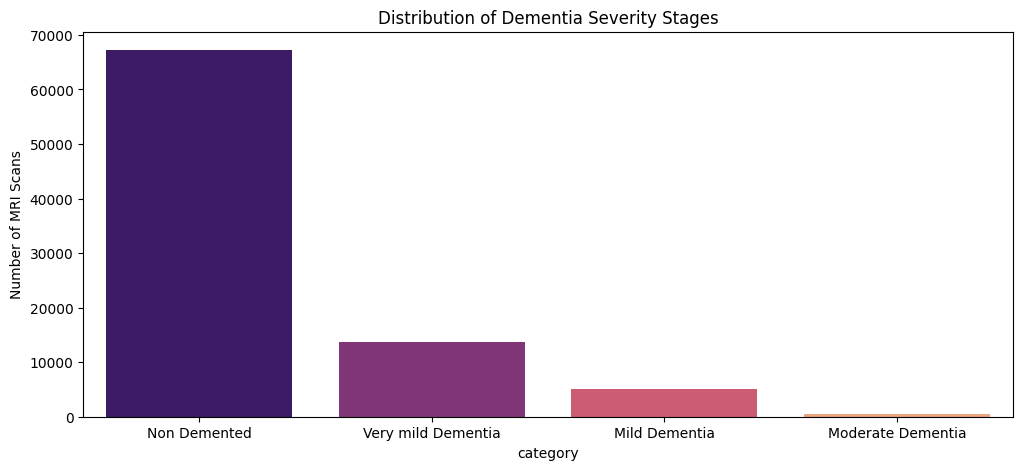

Extreme Imbalance Check (Non Demented vs Moderate): 137.8:1


In [5]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='category', order=categories.keys(), palette='magma')
plt.title('Distribution of Dementia Severity Stages')
plt.ylabel('Number of MRI Scans')
plt.show()

counts = df['category'].value_counts()
print(f"Extreme Imbalance Check (Non Demented vs Moderate): {counts['Non Demented']/counts['Moderate Dementia']:.1f}:1")

## 4. Patient-Level Splitting
To prevent **Data Leakage**, we split the dataset based on `patient_id`. This ensures that if a patient's brain appears in the training set, none of their MRI slices appear in the test set.

In [6]:
from sklearn.model_selection import train_test_split

# 1. Get unique human identifiers
unique_patients = df['patient_id'].unique()

# 2. Split patients: 80% Train, 20% Test
train_pats, test_pats = train_test_split(unique_patients, test_size=0.20, random_state=42)

# 3. Create initial DataFrames
train_df_raw = df[df['patient_id'].isin(train_pats)]
test_df = df[df['patient_id'].isin(test_pats)]

# 4. Split Train further into Train and Validation (10% of training humans for val)
train_pats, val_pats = train_test_split(train_pats, test_size=0.10, random_state=42)

train_df = train_df_raw[train_df_raw['patient_id'].isin(train_pats)]
val_df = train_df_raw[train_df_raw['patient_id'].isin(val_pats)]

print(f"✅ Splitting Complete:")
print(f"Training:   {len(train_pats)} Patients | {len(train_df)} Scans")
print(f"Validation: {len(val_pats)} Patients  | {len(val_df)} Scans")
print(f"Testing:    {len(test_pats)} Patients | {len(test_df)} Scans")

✅ Splitting Complete:
Training:   249 Patients | 62647 Scans
Validation: 28 Patients  | 7076 Scans
Testing:    70 Patients | 16714 Scans


## 5. Hybrid Resampling
To mitigate the **137:1 imbalance**, we perform hybrid resampling on the **Training Set only**.
* **Under-sampling:** Reducing the 'Non Demented' scans to a manageable number.
* **Over-sampling:** Replicating 'Moderate' and 'Mild' scans to increase their influence.
This ensures the CNN learns the features of every stage equally.

⬇️ Under-sampled Non Demented: 48800 -> 8000
⬇️ Under-sampled Very mild Dementia: 10248 -> 8000
⬆️ Over-sampled Mild Dementia: 3111 -> 8000
⬆️ Over-sampled Moderate Dementia: 488 -> 8000

✅ New Training Distribution:
category
Mild Dementia         8000
Very mild Dementia    8000
Non Demented          8000
Moderate Dementia     8000
Name: count, dtype: int64


/tmp/ipykernel_429/2680793062.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df_balanced, x='category', palette='viridis')


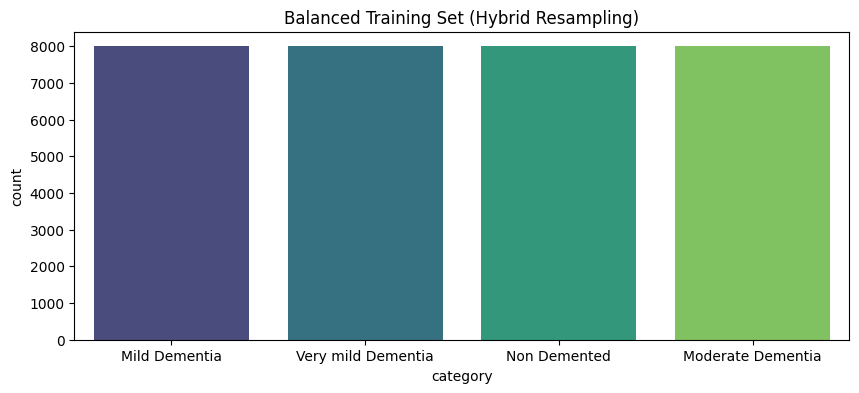

In [7]:
def perform_hybrid_resampling(df, target_samples_per_class=5000):
    resampled_segments = []

    for category in categories.keys():
        category_subset = df[df['category'] == category]
        current_count = len(category_subset)

        if current_count > target_samples_per_class:
            # Under-sample the majority classes
            resampled_data = category_subset.sample(target_samples_per_class, random_state=42)
            print(f"⬇️ Under-sampled {category}: {current_count} -> {target_samples_per_class}")
        else:
            # Over-sample the minority classes
            # We use 'replace=True' to duplicate existing scans
            resampled_data = category_subset.sample(target_samples_per_class, replace=True, random_state=42)
            print(f"⬆️ Over-sampled {category}: {current_count} -> {target_samples_per_class}")

        resampled_segments.append(resampled_data)

    return pd.concat(resampled_segments).sample(frac=1, random_state=42).reset_index(drop=True)

# Apply resampling to ONLY the training dataframe
train_df_balanced = perform_hybrid_resampling(train_df, target_samples_per_class=8000)

print("\n✅ New Training Distribution:")
print(train_df_balanced['category'].value_counts())

# Plot the new balanced distribution
plt.figure(figsize=(10, 4))
sns.countplot(data=train_df_balanced, x='category', palette='viridis')
plt.title('Balanced Training Set (Hybrid Resampling)')
plt.show()

In [8]:
## Cell 7: Memory-Safe Data Generator
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Standardizing image size
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Create a generator that reads from the DataFrame paths
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df_balanced,
    x_col="path",
    y_col="category", # Using the string names
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="sparse", # For ordinal labels (0, 1, 2, 3)
    shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="path",
    y_col="category",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=False
)

# Note: We do the same for test_generator later for evaluation

Found 32000 validated image filenames belonging to 4 classes.
Found 7076 validated image filenames belonging to 3 classes.


## 6. Data Pipelines (Memory-Safe Generators)
Instead of loading 80,000 images into RAM (which causes crashes), we use **Data Generators**.
These load images from the disk in small batches (32 at a time) during training.
* **Rescale:** Normalizes pixels to [0, 1] on-the-fly.
* **Class Mode 'sparse':** Directly supports our Ordinal (0, 1, 2, 3) labels.

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Configuration
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Explicitly define order to prevent label mismatch
class_list = ['Non Demented', 'Very mild Dementia', 'Mild Dementia', 'Moderate Dementia']

# 2. Define Normalization
datagen = ImageDataGenerator(rescale=1./255)

# 3. Training Generator
train_generator = datagen.flow_from_dataframe(
    dataframe=train_df_balanced,
    x_col="path",
    y_col="category",
    classes=class_list,  # Ensure consistent mapping
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=True
)

# 4. Validation Generator
val_generator = datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="path",
    y_col="category",
    classes=class_list, # Ensure consistent mapping
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=False
)

# 5. Test Generator
test_generator = datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="path",
    y_col="category",
    classes=class_list, # Ensure consistent mapping
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=False
)

Found 32000 validated image filenames belonging to 4 classes.
Found 7076 validated image filenames belonging to 4 classes.
Found 16714 validated image filenames belonging to 4 classes.


## 7. Custom 6-Block CNN Architecture
As per the project methodology, we implement a custom 6-block architecture.
Each block consists of: **Convolution -> BatchNormalization -> MaxPooling -> Dropout**.
* **Filter Progression:** 32 -> 64 -> 128 -> 256 -> 512 -> 512.
* **Dense Layer:** A single 256-unit hidden layer before the output to control parameter count.
* **Output:** 4 units with Softmax activation for the four severity stages.

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

def build_6_block_cnn(input_shape=(128, 128, 3)):
    model = Sequential([
        # Block 1
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.2),

        # Block 2
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.2),

        # Block 3
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.2),

        # Block 4
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.2),

        # Block 5
        Conv2D(512, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.3),

        # Block 6
        Conv2D(512, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.3),

        # Classification Head
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        # 4 units for the stages: None, Very Mild, Mild, Moderate
        Dense(4, activation='softmax')
    ])
    return model

# Initialize the model
model = build_6_block_cnn()

# Compile the model
# We use 'sparse_categorical_crossentropy' because our labels are integers (0-3)
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Check parameter count (Target: ~3.9M)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │             

 Total params: 4,459,972 (17.01 MB)

 Trainable params: 4,456,964 (17.00 MB)

 Non-trainable params: 3,008 (11.75 KB)

## 8. Model Training
To ensure the best version of the model is saved and to prevent overfitting, we implement two key Keras callbacks:
1. **ModelCheckpoint:** Saves only the version of the model that achieves the lowest validation loss.
2. **EarlyStopping:** Stops training if the validation loss does not improve for 5 consecutive epochs.

In [11]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Define callbacks
checkpoint = ModelCheckpoint(
    'best_dementia_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Start training
# Note: steps_per_epoch is total_samples / batch_size
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    callbacks=[checkpoint, early_stop],
    verbose=1
)

Epoch 1/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4458 - loss: 1.4497
Epoch 1: val_loss improved from None to 1.39249, saving model to best_dementia_model.h5



Epoch 1: finished saving model to best_dementia_model.h5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 60s 45ms/step - accuracy: 0.5449 - loss: 1.0676 - val_accuracy: 0.7920 - val_loss: 1.3925
Epoch 2/50
 999/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7276 - loss: 0.6333
Epoch 2: val_loss improved from 1.39249 to 1.11010, saving model to best_dementia_model.h5



Epoch 2: finished saving model to best_dementia_model.h5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 42s 42ms/step - accuracy: 0.7516 - loss: 0.5739 - val_accuracy: 0.8068 - val_loss: 1.1101
Epoch 3/50
 999/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8285 - loss: 0.4186
Epoch 3: val_loss improved from 1.11010 to 1.09782, saving model to best_dementia_model.h5



Epoch 3: finished saving model to best_dementia_model.h5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 40s 40ms/step - accuracy: 0.8462 - loss: 0.3768 - val_accuracy: 0.7917 - val_loss: 1.0978
Epoch 4/50
 999/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8918 - loss: 0.2661
Epoch 4: val_loss did not improve from 1.09782
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 40s 40ms/step - accuracy: 0.9008 - loss: 0.2440 - val_accuracy: 0.7328 - val_loss: 1.2727
Epoch 5/50
 999/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9295 - loss: 0.1779
Epoch 5: val_loss did not improve from 1.09782
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 40s 40ms/step - accuracy: 0.9348 - loss: 0.1690 - val_accuracy: 0.7296 - val_loss: 1.6184
Epoch 6/50
 999/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9491 - loss: 0.1284
Epoch 6: val_loss did not improve from 1.09782
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - accuracy: 0.9518 - loss: 0.1245 - val_accuracy: 0.7629 - val_loss: 1.6279
Epoch 7/50
 999/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/

## 9. Final Model Evaluation
We evaluate the trained model using the **Test Generator**, which contains MRI scans from 70 patients that the model has never encountered. This provides a true measure of the system's diagnostic robustness and generalizability.

In [12]:
# Load the best weights saved during training
model.load_weights('best_dementia_model.h5')

# Evaluate on the test set
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)

print(f"\n✅ Test Accuracy: {test_accuracy*100:.2f}%")
print(f"✅ Test Loss: {test_loss:.4f}")

523/523 ━━━━━━━━━━━━━━━━━━━━ 20s 37ms/step - accuracy: 0.6660 - loss: 1.8993

✅ Test Accuracy: 66.60%
✅ Test Loss: 1.8993


## 10. Visualization: Confusion Matrix
To understand how the model performs across different early dementia severity stages, we generate a confusion matrix. This visualization helps identify if the model is confusing consecutive stages, such as 'Non-Demented' and 'Very Mild'.

523/523 ━━━━━━━━━━━━━━━━━━━━ 19s 34ms/step


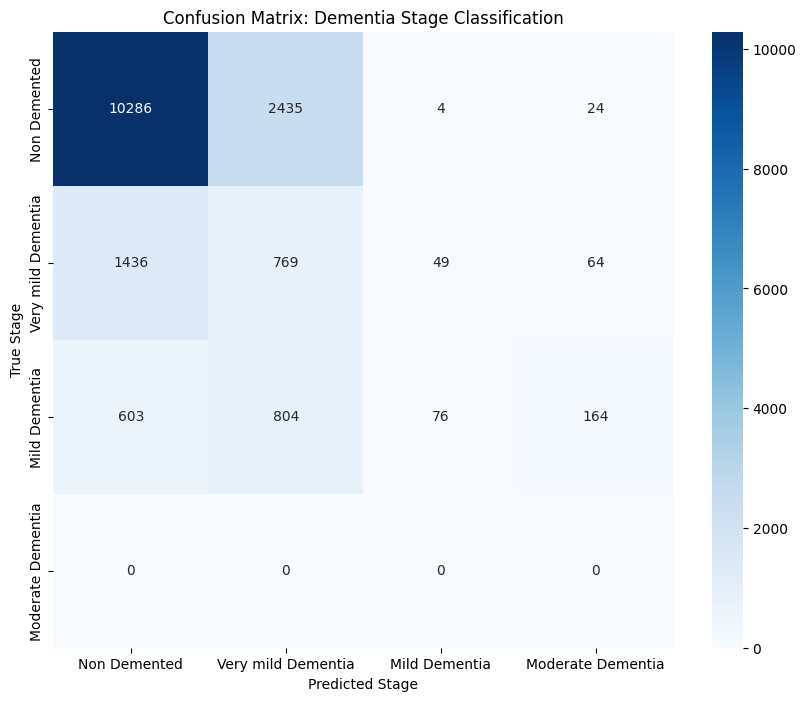


Detailed Classification Report:
                    precision    recall  f1-score   support

      Non Demented       0.83      0.81      0.82     12749
Very mild Dementia       0.19      0.33      0.24      2318
     Mild Dementia       0.59      0.05      0.09      1647
 Moderate Dementia       0.00      0.00      0.00         0

          accuracy                           0.67     16714
         macro avg       0.40      0.30      0.29     16714
      weighted avg       0.72      0.67      0.67     16714



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [13]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# 1. Get predictions for the test set
# We set shuffle=False in the generator to ensure labels match predictions
test_generator.reset()
predictions = model.predict(test_generator, verbose=1)
y_pred = np.argmax(predictions, axis=1)

# 2. Get true labels from the generator
y_true = test_generator.classes

# 3. Generate the Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# 4. Plotting
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=list(categories.keys()),
    yticklabels=list(categories.keys())
)
plt.title('Confusion Matrix: Dementia Stage Classification')
plt.ylabel('True Stage')
plt.xlabel('Predicted Stage')
plt.show()

# 5. Print Detailed Classification Report
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=list(categories.keys())))

## 11. Learning Curves
We plot the training and validation accuracy/loss to confirm that the model converged successfully and to check for any signs of late-stage overfitting.

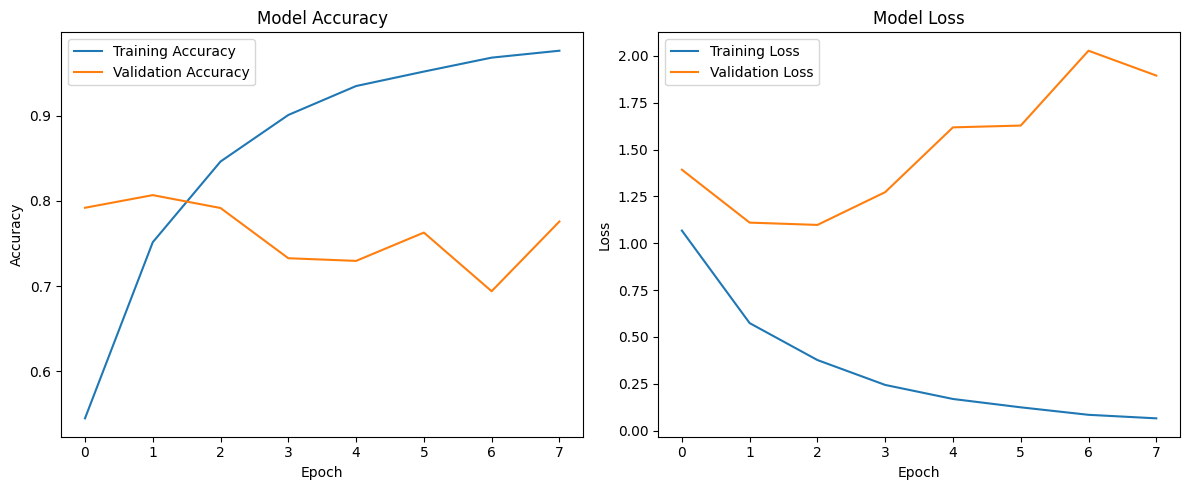

In [14]:
# Plot Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## 12. Exporting for Deployment
To enable the **sub-second inference** described in the project summary, we save the model in the standardized Keras `.h5` format. This file contains the architecture, weights, and optimizer state, allowing it to be loaded directly into a **Streamlit** web application.

In [15]:
# Save the model to your Google Drive for permanent storage
model_save_path = os.path.join(PROJECT_FOLDER, 'dementia_detection_model_final.h5')
model.save(model_save_path)

print(f"✅ Model successfully exported to: {model_save_path}")

✅ Model successfully exported to: /content/drive/MyDrive/OASIS_Project/dementia_detection_model_final.h5
